# SE3 Imbalance — Spike Detection Notebook

Reframes the imbalance forecasting problem from **regression** (predict the price)
to **classification** (detect whether the next period will be a stress or spike event).

This mirrors the cancer-detection framing:
- Most periods are "normal" (benign)
- A small fraction are "stress" or "extreme" (malignant)
- Missing a spike costs far more than a false alarm
- Optimize for **recall on the positive (spike) class**, not overall accuracy

**Pipeline:**
1. Data — same eSett + Open-Meteo fetch as the forecasting notebook (no DuckDB)
2. Spike label engineering — define classes with clinical precision
3. Feature engineering — all features from the forecasting notebook PLUS new
   spike-specific features (volatility acceleration, direction instability,
   reg-spread momentum, reserve-stress proxies)
4. Temporal encoding — encode "memory" without leaking future price
5. EDA on class imbalance — understand the rarity problem
6. Resampling — BorderlineSMOTE + Tomek links on training data only
7. Train — LightGBM multi-class classifier with asymmetric class weights
8. Evaluate — confusion matrix, precision/recall, AUC-ROC, profit curve
9. Threshold tuning — cost-sensitive operating point
10. Summary and next steps


## 0. Imports & Config

In [1]:
from __future__ import annotations

import logging
import os
import warnings
from datetime import date, timedelta
from pathlib import Path

import holidays
import lightgbm as lgb
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import requests
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    precision_recall_curve, roc_curve, ConfusionMatrixDisplay,
)
from sklearn.preprocessing import label_binarize

try:
    from imblearn.over_sampling import BorderlineSMOTE
    from imblearn.combine import SMOTETomek
    from imblearn.under_sampling import TomekLinks
    HAS_IMBLEARN = True
except ImportError:
    HAS_IMBLEARN = False
    print("WARNING: imbalanced-learn not installed. Run: pip install imbalanced-learn")

warnings.filterwarnings("ignore")
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    datefmt="%H:%M:%S",
)
log = logging.getLogger("spike_detection")

# ── Constants ──────────────────────────────────────────────────────────────────
WEATHER_LAT:  float = 59.33
WEATHER_LON:  float = 18.07
SE3_MBA:      str   = "10Y1001A1001A46L"
FETCH_MONTHS: int   = 18
CHUNK_MONTHS: int   = 2
TEST_DAYS:    int   = 60
FIGURES_DIR         = Path("figures/spike_detection")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# ── Spike thresholds (EUR/MWh) ─────────────────────────────────────────────────
# Class 0: Normal long  — system long, low price       (direction = -1, price < NORMAL_HIGH)
# Class 1: Normal short — system short, moderate price (direction = +1, price < STRESS_LOW)
# Class 2: Stress       — price > STRESS_HIGH or < STRESS_LOW (moderate tail)
# Class 3: Extreme      — price > EXTREME_HIGH or < EXTREME_LOW (far tail)
#
# Thresholds set from EDA: p90 ~ 200, p95 ~ 400, p99 ~ 1500
STRESS_HIGH:  float = 200.0    # EUR/MWh — upper stress boundary
STRESS_LOW:   float = -100.0   # EUR/MWh — lower stress boundary
EXTREME_HIGH: float = 1000.0   # EUR/MWh — upper extreme boundary
EXTREME_LOW:  float = -500.0   # EUR/MWh — lower extreme boundary

# ── Trading cost asymmetry ─────────────────────────────────────────────────────
# Used for threshold tuning: how bad is missing a spike vs false alarming?
COST_FALSE_NEGATIVE: float = 300.0  # EUR/MWh opportunity cost of being unhedged
COST_FALSE_POSITIVE: float = 15.0   # EUR/MWh cost of unnecessary battery action

# ── LightGBM params (matching ml.py) ──────────────────────────────────────────
LGBM_PARAMS: dict = {
    "n_estimators":      2000,
    "learning_rate":     0.05,
    "num_leaves":        63,
    "min_child_samples": 20,
    "feature_fraction":  0.8,
    "bagging_fraction":  0.8,
    "bagging_freq":      5,
    "verbose":          -1,
}

SE_HOLIDAYS = holidays.Sweden()
ENTSOE_KEY  = os.environ.get("ENTSOE_API_KEY", "")

print(f"ENTSOE key available : {bool(ENTSOE_KEY)}")
print(f"imbalanced-learn     : {HAS_IMBLEARN}")
print(f"LightGBM version     : {lgb.__version__}")
print(f"\nSpike thresholds:")
print(f"  Stress:  price > {STRESS_HIGH} or < {STRESS_LOW} EUR/MWh")
print(f"  Extreme: price > {EXTREME_HIGH} or < {EXTREME_LOW} EUR/MWh")


ENTSOE key available : True
imbalanced-learn     : True
LightGBM version     : 4.6.0

Spike thresholds:
  Stress:  price > 200.0 or < -100.0 EUR/MWh
  Extreme: price > 1000.0 or < -500.0 EUR/MWh


## 1. Fetch Data

Identical fetch logic to the forecasting notebook — same eSett and Open-Meteo
calls, same alignment to 15-min index. No DuckDB required.


In [2]:
ESETT_URL = "https://api.opendata.esett.com/EXP14/Prices"


def _encode_direction(raw: pd.Series) -> pd.Series:
    if raw.dtype == object:
        dmap = {"LONG": -1, "NEUTRAL": 0, "SHORT": 1}
        return raw.str.upper().map(dmap).fillna(0).astype(int)
    return np.sign(pd.to_numeric(raw, errors="coerce").fillna(0)).astype(int)


def _fetch_imbalance_chunk(start: date, end: date) -> pd.DataFrame:
    from datetime import datetime as _dt, timezone as _tz
    start_dt = _dt(start.year, start.month, start.day, 0, 0, 0, tzinfo=_tz.utc)
    end_dt   = _dt(end.year,   end.month,   end.day,   23, 59, 59, tzinfo=_tz.utc)
    params   = {
        "start": start_dt.strftime("%Y-%m-%dT%H:%M:%S.000Z"),
        "end":   end_dt.strftime("%Y-%m-%dT%H:%M:%S.000Z"),
        "mba":   SE3_MBA,
    }
    r = requests.get(ESETT_URL, params=params, timeout=90)
    r.raise_for_status()
    data    = r.json()
    records = data if isinstance(data, list) else data.get("data", [])
    if not records:
        return pd.DataFrame()
    df = pd.DataFrame(records)
    ts_col = next((c for c in ["timestampUTC", "timestamp"] if c in df.columns), None)
    if ts_col is None:
        return pd.DataFrame()
    raw_ts = pd.to_datetime(df[ts_col])
    if ts_col == "timestampUTC":
        df["timestamp"] = (raw_ts.dt.tz_localize("UTC")
                           if raw_ts.dt.tz is None else raw_ts.dt.tz_convert("UTC"))
        df["timestamp"] = df["timestamp"].dt.tz_convert("Europe/Stockholm")
    else:
        df["timestamp"] = (raw_ts.dt.tz_localize("Europe/Stockholm",
                           ambiguous="infer", nonexistent="shift_forward")
                           if raw_ts.dt.tz is None else raw_ts.dt.tz_convert("Europe/Stockholm"))
    rename = {
        "imblSalesPrice":          "imbl_price",
        "mainDirRegPowerPerMBA":   "direction_raw",
        "imblSpotDifferencePrice": "imbl_spot_diff",
        "upRegPrice":              "up_reg_price",
        "downRegPrice":            "down_reg_price",
    }
    df = df.rename(columns=rename).set_index("timestamp").sort_index()
    df["direction"] = _encode_direction(df["direction_raw"]) if "direction_raw" in df.columns else 0
    keep = [c for c in ["imbl_price","direction","imbl_spot_diff",
                         "up_reg_price","down_reg_price"] if c in df.columns]
    return df[keep].apply(pd.to_numeric, errors="coerce")


def fetch_all_imbalance(months: int = FETCH_MONTHS) -> pd.DataFrame:
    end_dt   = date.today()
    start_dt = end_dt - timedelta(days=int(months * 30.5))
    chunks: list[pd.DataFrame] = []
    current = start_dt
    while current < end_dt:
        m2       = current.month + CHUNK_MONTHS
        y2       = current.year + (m2 - 1) // 12
        m2       = (m2 - 1) % 12 + 1
        chunk_end = min(date(y2, m2, 1) - timedelta(days=1), end_dt)
        log.info("Fetching imbalance %s → %s", current, chunk_end)
        try:
            chunk = _fetch_imbalance_chunk(current, chunk_end)
            if not chunk.empty:
                chunks.append(chunk)
        except requests.RequestException as exc:
            log.warning("eSett fetch failed: %s", exc)
        current = chunk_end + timedelta(days=1)
    if not chunks:
        raise RuntimeError("No imbalance data fetched.")
    df = pd.concat(chunks)
    return df[~df.index.duplicated(keep="first")].sort_index()


def fetch_weather(start: date, end: date) -> pd.DataFrame:
    end_capped = min(end, date.today() - timedelta(days=2))
    r = requests.get(
        "https://archive-api.open-meteo.com/v1/archive",
        params={
            "latitude": WEATHER_LAT, "longitude": WEATHER_LON,
            "start_date": start.isoformat(), "end_date": end_capped.isoformat(),
            "hourly": "temperature_2m,windspeed_10m,windspeed_100m,direct_radiation,cloudcover",
            "timezone": "UTC",
        }, timeout=120)
    r.raise_for_status()
    h  = r.json()["hourly"]
    df = pd.DataFrame({
        "timestamp":       pd.to_datetime(h["time"]),
        "temperature":     h.get("temperature_2m"),
        "windspeed_10m":   h.get("windspeed_10m"),
        "windspeed_100m":  h.get("windspeed_100m"),
        "solar_radiation": h.get("direct_radiation"),
        "cloudcover":      h.get("cloudcover"),
    })
    df["timestamp"] = df["timestamp"].dt.tz_localize("UTC").dt.tz_convert("Europe/Stockholm")
    df = df.set_index("timestamp").sort_index()
    idx_15 = pd.date_range(df.index.min(), df.index.max(), freq="15min", tz="Europe/Stockholm")
    return df.reindex(idx_15).ffill()


# ── Fetch all data ─────────────────────────────────────────────────────────────
print("Fetching imbalance data from eSett...")
df_imbl    = fetch_all_imbalance()
start_date = df_imbl.index.min().date()
end_date   = df_imbl.index.max().date()

print(f"\nFetching weather from Open-Meteo ({start_date} → {end_date})...")
df_weather = fetch_weather(start_date, end_date)

# Optional spot prices
df_spot = pd.DataFrame(index=df_weather.index, columns=["spot_price"], dtype=float)
if ENTSOE_KEY:
    try:
        from entsoe import EntsoePandasClient
        client = EntsoePandasClient(api_key=ENTSOE_KEY)
        s = pd.Timestamp(start_date.isoformat(), tz="Europe/Stockholm")
        e = pd.Timestamp(end_date.isoformat(),   tz="Europe/Stockholm")
        raw = client.query_day_ahead_prices(SE3_MBA, start=s, end=e).rename("spot_price").to_frame()
        raw.index = raw.index.tz_convert("Europe/Stockholm")
        idx_15 = pd.date_range(raw.index.min(), raw.index.max(), freq="15min", tz="Europe/Stockholm")
        df_spot = raw.reindex(idx_15).ffill()
        print(f"Spot prices loaded: {len(df_spot):,} rows")
    except Exception as exc:
        print(f"Spot prices unavailable: {exc}")

# Merge
df_merged = df_imbl.join(df_weather, how="left").join(df_spot, how="left")
df_merged = df_merged.dropna(subset=["imbl_price"])
print(f"\nMerged: {len(df_merged):,} rows × {len(df_merged.columns)} cols")
print(f"Period: {df_merged.index.min().date()} → {df_merged.index.max().date()}")
df_merged.head(3)


23:08:24 [INFO] Fetching imbalance 2024-12-03 → 2025-01-31


Fetching imbalance data from eSett...


23:08:25 [INFO] Fetching imbalance 2025-02-01 → 2025-03-31
23:08:26 [INFO] Fetching imbalance 2025-04-01 → 2025-05-31
23:08:26 [INFO] Fetching imbalance 2025-06-01 → 2025-07-31
23:08:26 [INFO] Fetching imbalance 2025-08-01 → 2025-09-30
23:08:27 [INFO] Fetching imbalance 2025-10-01 → 2025-11-30
23:08:27 [INFO] Fetching imbalance 2025-12-01 → 2026-01-31
23:08:27 [INFO] Fetching imbalance 2026-02-01 → 2026-03-31
23:08:27 [INFO] Fetching imbalance 2026-04-01 → 2026-05-31
23:08:28 [INFO] Fetching imbalance 2026-06-01 → 2026-06-05



Fetching weather from Open-Meteo (2024-12-03 → 2026-06-06)...
Spot prices loaded: 52,797 rows

Merged: 52,778 rows × 11 cols
Period: 2024-12-03 → 2026-06-05


,imbl_price,direction,imbl_spot_diff,up_reg_price,down_reg_price,temperature,windspeed_10m,windspeed_100m,solar_radiation,cloudcover,spot_price
timestamp,,,,,,,,,,,
2024-12-03 01:00:00+01:00,24.48,0,0.0,24.48,24.48,5.1,9.1,15.3,0.0,100.0,24.48
2024-12-03 01:15:00+01:00,24.48,0,0.0,24.48,24.48,5.1,9.1,15.3,0.0,100.0,24.48
2024-12-03 01:30:00+01:00,24.48,0,0.0,24.48,24.48,5.1,9.1,15.3,0.0,100.0,24.48


## 2. Spike Label Engineering

Define four classes based on price thresholds derived from the EDA percentiles.
The class boundaries are clinical, not arbitrary — set at meaningful market stress levels.

| Class | Label | Condition | Analogy |
|---|---|---|---|
| 0 | Normal | price in [STRESS_LOW, STRESS_HIGH] | Benign |
| 1 | Stress | price in [STRESS_HIGH, EXTREME_HIGH] or [EXTREME_LOW, STRESS_LOW] | Suspicious |
| 2 | Extreme | price > EXTREME_HIGH or < EXTREME_LOW | Malignant |

We also create a **binary label** (spike = classes 1+2 vs normal = class 0)
for simpler threshold tuning and the profit curve.

**Key design choice:** Labels are assigned based on the **target period** (t+1),
not the current period. The model never sees the future price — it only uses
lagged features at time t to predict the class of t+1.


In [3]:
def assign_spike_class(price: pd.Series) -> pd.Series:
    """
    Assign spike class to each 15-min period.

    Classes
    -------
    0 : Normal  — price within [-100, 200] EUR/MWh
    1 : Stress  — price in (200, 1000] or [-500, -100)
    2 : Extreme — price > 1000 or < -500

    Parameters
    ----------
    price : pd.Series  Raw imbalance price (not shifted — applied to target period).

    Returns
    -------
    pd.Series  Integer class label {0, 1, 2}.
    """
    cls = pd.Series(0, index=price.index, dtype=int)
    # Stress: moderate tails
    cls[(price > STRESS_HIGH)  & (price <= EXTREME_HIGH)] = 1
    cls[(price < STRESS_LOW)   & (price >= EXTREME_LOW)]  = 1
    # Extreme: far tails
    cls[price > EXTREME_HIGH] = 2
    cls[price < EXTREME_LOW]  = 2
    return cls


# Assign labels on full dataset (used only to create the target column)
df_merged["spike_class"]  = assign_spike_class(df_merged["imbl_price"])
df_merged["is_spike"]     = (df_merged["spike_class"] > 0).astype(int)  # binary

# ── Class distribution ─────────────────────────────────────────────────────────
class_counts = df_merged["spike_class"].value_counts().sort_index()
class_labels = {0: "Normal", 1: "Stress", 2: "Extreme"}
total        = len(df_merged)

print("Class distribution (full dataset):")
for cls, cnt in class_counts.items():
    pct = cnt / total * 100
    print(f"  Class {cls} ({class_labels[cls]:<8}): {cnt:6,} ({pct:.2f}%)")

print(f"\nSpike prevalence (class 1+2): {(df_merged['is_spike'].sum()/total)*100:.2f}%")
print(f"Extreme prevalence (class 2): {(df_merged['spike_class']==2).mean()*100:.3f}%")


Class distribution (full dataset):
  Class 0 (Normal  ): 50,505 (95.69%)
  Class 1 (Stress  ):  2,102 (3.98%)
  Class 2 (Extreme ):    171 (0.32%)

Spike prevalence (class 1+2): 4.31%
Extreme prevalence (class 2): 0.324%


## 3. Feature Engineering

Extends the forecasting notebook's feature set with **spike-specific features**
designed to detect building stress signals.

### Strict leakage rules
- All features use `.shift(1)` or `.shift(n)` on price/direction
- Weather features are at time t (observed — valid for nowcasting)
- Target is assigned to t+1 (horizon=1 by default)
- No future price, direction, or regulation data enters any feature

### New features added for spike detection

| Feature | Signal | Leakage guard |
|---|---|---|
| `imbl_abs_lag1` | Magnitude of last price | shift(1) |
| `imbl_roll_1h_max` | Recent price peak | shift(1).rolling |
| `imbl_roll_4h_max` | 4h price peak | shift(1).rolling |
| `vol_acceleration` | Is volatility rising? | derived from shifted rolling |
| `dir_flip_rate_1h` | Direction instability | shift(1) on direction |
| `dir_flip_rate_4h` | Direction instability | shift(1) on direction |
| `reg_spread_roll` | Regulation spread momentum | shift(1).rolling |
| `reg_spread_accel` | Is spread widening? | diff on shifted rolling |
| `price_zscore_1h` | How extreme vs recent history | shift(1) |
| `price_zscore_4h` | How extreme vs 4h history | shift(1) |
| `consecutive_high` | Streak of high prices | shift(1) |
| `stress_proximity` | Distance from stress threshold | shift(1) |
| `reserve_stress_proxy` | reg_spread × is_peak × season | derived |
| Temporal embeddings | Cyclical time without price | deterministic |


In [4]:
def _direction_streak(d: pd.Series) -> pd.Series:
    """Vectorised run-length count of consecutive same-direction periods.
    Uses lagged direction to avoid leakage."""
    d_lag     = d.shift(1)
    changes   = (d_lag != d_lag.shift(1)).cumsum()
    streak    = changes.groupby(changes).cumcount() + 1
    return streak.where(d_lag.notna(), other=np.nan)


def build_spike_features(df: pd.DataFrame, horizon: int = 1) -> pd.DataFrame:
    """
    Build feature matrix for spike detection.

    Includes all features from the forecasting notebook plus spike-specific
    features. Target is spike_class at t+horizon.

    All price/direction-derived features are strictly lagged.
    Weather is at time t (observed — no leakage for short-horizon nowcasting).
    """
    X   = df.copy()
    X.index = pd.to_datetime(X.index)
    if X.index.tz is None:
        X.index = X.index.tz_localize(
            "Europe/Stockholm", ambiguous="infer", nonexistent="shift_forward")

    p = X["imbl_price"]
    d = X["direction"].astype(float) if "direction" in X.columns else pd.Series(0, index=X.index)

    # ─────────────────────────────────────────────────────────────────────────
    # A. BASE FEATURES (from forecasting notebook — identical, no leakage)
    # ─────────────────────────────────────────────────────────────────────────

    # Price lags
    for lag in [1, 2, 4, 8, 16]:
        X[f"imbl_lag_{lag}"] = p.shift(lag)
    X["imbl_lag_1h"] = p.shift(4)
    X["imbl_lag_2h"] = p.shift(8)
    X["imbl_lag_4h"] = p.shift(16)

    # Direction lags
    for lag in [1, 2, 4, 8]:
        X[f"dir_lag_{lag}"] = d.shift(lag)
    X["dir_streak"] = _direction_streak(d)

    # Rolling stats (all shifted before rolling)
    p1 = p.shift(1)
    X["imbl_roll_1h_mean"] = p1.rolling(4).mean()
    X["imbl_roll_1h_std"]  = p1.rolling(4).std()
    X["imbl_roll_4h_mean"] = p1.rolling(16).mean()
    X["imbl_roll_4h_std"]  = p1.rolling(16).std()
    X["imbl_roll_1d_mean"] = p1.rolling(96).mean()
    X["imbl_ewa"]          = p1.ewm(span=8, adjust=False).mean()

    # Regulation spread
    if ("up_reg_price" in X.columns and "down_reg_price" in X.columns
            and X["up_reg_price"].notna().any()):
        X["reg_spread"] = (X["up_reg_price"] - X["down_reg_price"]).shift(1)
    if "imbl_spot_diff" in X.columns and X["imbl_spot_diff"].notna().any():
        X["imbl_spot_diff_lag1"] = X["imbl_spot_diff"].shift(1)
    if "spot_price" in X.columns and X["spot_price"].notna().any():
        X["spot_price_lag1"] = X["spot_price"].shift(1)

    # ─────────────────────────────────────────────────────────────────────────
    # B. SPIKE-SPECIFIC FEATURES (new — all strictly lagged)
    # ─────────────────────────────────────────────────────────────────────────

    # B1. Price magnitude and tail proximity
    X["imbl_abs_lag1"]      = p.shift(1).abs()
    X["imbl_roll_1h_max"]   = p1.rolling(4).max()   # recent price ceiling
    X["imbl_roll_4h_max"]   = p1.rolling(16).max()  # 4h price ceiling
    X["imbl_roll_1h_min"]   = p1.rolling(4).min()   # recent price floor
    X["imbl_roll_4h_min"]   = p1.rolling(16).min()  # 4h price floor

    # How many standard deviations from recent mean? (z-score)
    # Positive z-score = above recent mean = potential up-spike
    eps = 1e-6
    X["price_zscore_1h"] = (
        (p.shift(1) - X["imbl_roll_1h_mean"]) / (X["imbl_roll_1h_std"] + eps)
    )
    X["price_zscore_4h"] = (
        (p.shift(1) - X["imbl_roll_4h_mean"]) / (X["imbl_roll_4h_std"] + eps)
    )

    # Proximity to stress threshold (how far are we from danger zone?)
    # Negative = already in stress zone, positive = approaching from below
    X["stress_proximity_up"]   = STRESS_HIGH  - p.shift(1)
    X["stress_proximity_down"] = p.shift(1)   - STRESS_LOW
    # Clipped: only care about how close, not how far inside
    X["stress_proximity_up"]   = X["stress_proximity_up"].clip(upper=STRESS_HIGH)
    X["stress_proximity_down"] = X["stress_proximity_down"].clip(upper=abs(STRESS_LOW))

    # Streak of prices above stress threshold (consecutive stress periods)
    above_stress    = (p.shift(1).abs() > STRESS_HIGH).astype(int)
    stress_changes  = (above_stress != above_stress.shift(1)).cumsum()
    X["consecutive_stress"] = (
        above_stress.groupby(stress_changes).cumcount() * above_stress
    )

    # B2. Volatility acceleration — is volatility RISING?
    # vol_accel > 0 means recent volatility higher than 4h volatility
    X["vol_acceleration"] = X["imbl_roll_1h_std"] - X["imbl_roll_4h_std"]

    # Price change momentum (is price moving away from mean quickly?)
    X["price_momentum_1h"] = p.shift(1) - p.shift(5)   # change over last 1h
    X["price_momentum_4h"] = p.shift(1) - p.shift(17)  # change over last 4h

    # B3. Direction instability — how many direction flips in recent window?
    # More flips = system is unstable = higher spike risk
    d1 = d.shift(1)
    dir_flip = (d1 != d1.shift(1)).astype(int)
    X["dir_flip_rate_1h"] = dir_flip.rolling(4).sum()   # flips in last 1h
    X["dir_flip_rate_4h"] = dir_flip.rolling(16).sum()  # flips in last 4h
    X["dir_flip_rate_1d"] = dir_flip.rolling(96).sum()  # flips in last 1d

    # B4. Regulation spread momentum — is the up/down spread widening?
    if "reg_spread" in X.columns:
        rs = X["reg_spread"]  # already shifted(1)
        X["reg_spread_roll_1h"] = rs.rolling(4).mean()
        X["reg_spread_roll_4h"] = rs.rolling(16).mean()
        X["reg_spread_accel"]   = rs.rolling(4).mean() - rs.rolling(16).mean()
        # Large positive = spread widening fast = system under stress
        X["reg_spread_x_peak"]  = rs * (X.index.hour.isin(range(7, 10)) |
                                        X.index.hour.isin(range(17, 21))).astype(int)

    # B5. Reserve stress proxy: high reg_spread during peak hours in winter
    # This captures the "perfect storm" regime that drives extreme events
    is_winter = X.index.month.isin([12, 1, 2]).astype(int)
    is_peak   = (X.index.hour.isin(range(7, 10)) |
                 X.index.hour.isin(range(17, 21))).astype(int)
    if "reg_spread" in X.columns:
        X["reserve_stress_proxy"] = X["reg_spread"] * is_peak * is_winter

    # B6. Regime transition features — has the system recently flipped regime?
    # System went from long to short = potential for price spike
    d_lag1 = d.shift(1)
    d_lag2 = d.shift(2)
    X["regime_flip_to_short"] = ((d_lag1 == 1) & (d_lag2 == -1)).astype(int)
    X["regime_flip_to_long"]  = ((d_lag1 == -1) & (d_lag2 == 1)).astype(int)

    # B7. Time since last stress event — how "overdue" is a spike?
    # Large value = many normal periods since last stress = due for a spike
    in_stress_lag = (p.shift(1).abs() > STRESS_HIGH).astype(int)
    time_since    = []
    counter       = 0
    for v in in_stress_lag:
        if v == 1:
            counter = 0
        else:
            counter += 1
        time_since.append(counter)
    X["periods_since_stress"] = time_since

    # ─────────────────────────────────────────────────────────────────────────
    # C. CALENDAR & TEMPORAL ENCODING (deterministic — no leakage possible)
    # ─────────────────────────────────────────────────────────────────────────

    X["hour"]      = X.index.hour
    X["minute"]    = X.index.minute
    X["dayofweek"] = X.index.dayofweek
    X["month"]     = X.index.month
    X["slot"]      = X["hour"] * 4 + X["minute"] // 15   # 0..95

    # Fourier encodings (encode periodicity without discrete bins)
    X["hour_sin"]  = np.sin(2 * np.pi * X["hour"]      / 24)
    X["hour_cos"]  = np.cos(2 * np.pi * X["hour"]      / 24)
    X["dow_sin"]   = np.sin(2 * np.pi * X["dayofweek"] / 7)
    X["dow_cos"]   = np.cos(2 * np.pi * X["dayofweek"] / 7)
    X["month_sin"] = np.sin(2 * np.pi * X["month"]     / 12)
    X["month_cos"] = np.cos(2 * np.pi * X["month"]     / 12)
    X["slot_sin"]  = np.sin(2 * np.pi * X["slot"]      / 96)
    X["slot_cos"]  = np.cos(2 * np.pi * X["slot"]      / 96)

    how = X["dayofweek"] * 96 + X["slot"]
    hoy = (X.index.dayofyear - 1) * 96 + X["slot"]
    for k in [1, 2, 3]:
        X[f"daily_sin_k{k}"]  = np.sin(2 * np.pi * k * X["slot"] / 96)
        X[f"daily_cos_k{k}"]  = np.cos(2 * np.pi * k * X["slot"] / 96)
        X[f"weekly_sin_k{k}"] = np.sin(2 * np.pi * k * how / (7 * 96))
        X[f"weekly_cos_k{k}"] = np.cos(2 * np.pi * k * how / (7 * 96))
    for k in [1, 2]:
        X[f"annual_sin_k{k}"] = np.sin(2 * np.pi * k * hoy / (365 * 96))
        X[f"annual_cos_k{k}"] = np.cos(2 * np.pi * k * hoy / (365 * 96))

    X["season"]     = X["month"].map({12:1,1:1,2:1,3:2,4:2,5:2,6:3,7:3,8:3,9:4,10:4,11:4})
    X["is_weekend"] = (X.index.dayofweek >= 5).astype(int)
    X["is_holiday"] = X.index.normalize().map(lambda d_: int(d_ in SE_HOLIDAYS))
    X["is_peak"]    = is_peak
    X["is_night"]   = X["hour"].isin([23,0,1,2,3,4,5]).astype(int)
    X["is_winter"]  = is_winter

    # ─────────────────────────────────────────────────────────────────────────
    # D. WEATHER FEATURES (observed at t — no leakage for nowcasting)
    # ─────────────────────────────────────────────────────────────────────────

    wind_col = "windspeed_100m" if "windspeed_100m" in X.columns else "windspeed_10m"
    if wind_col in X.columns:
        w = X[wind_col]
        X["wind_7d_mean"]  = w.rolling(672, min_periods=48).mean()
        X["wind_surprise"] = w - X["wind_7d_mean"]
        X["wind_x_night"]  = w * X["is_night"]
        X["wind_x_peak"]   = w * X["is_peak"]
        X["wind_squared"]  = w ** 2
        # Wind surprise × stress proximity: low wind + approaching threshold = dangerous
        if "stress_proximity_up" in X.columns:
            X["wind_surprise_x_stress"] = X["wind_surprise"] * (
                STRESS_HIGH / (X["stress_proximity_up"] + 1))

    if "temperature" in X.columns:
        X["heating_degree"]  = (15 - X["temperature"]).clip(lower=0)
        X["temp_x_peak"]     = X["temperature"] * X["is_peak"]
        X["temp_x_winter"]   = X["temperature"] * X["is_winter"]
        # Heating degree × peak × winter: high demand stress signal
        X["demand_stress"]   = X["heating_degree"] * X["is_peak"] * X["is_winter"]

    if "cloudcover" in X.columns:
        X["cloudcover_lag1"] = X["cloudcover"].shift(1)

    # ─────────────────────────────────────────────────────────────────────────
    # E. TARGET — spike class at t+horizon (never enters features)
    # ─────────────────────────────────────────────────────────────────────────

    # Target: class of the NEXT period
    X["target_class"]  = X["spike_class"].shift(-horizon)
    X["target_binary"] = X["is_spike"].shift(-horizon)

    return X


In [5]:
# Build features
print("Building spike detection features...")
df_feats = build_spike_features(df_merged.copy(), horizon=1)

# ── Feature column selection (same safety-net pattern as forecasting notebook)
def make_spike_feature_cols(df: pd.DataFrame) -> list[str]:
    """Return ordered feature list, excluding target and raw price columns."""
    # Group A: base lags
    base = (
        [f"imbl_lag_{l}" for l in [1,2,4,8,16]]
        + ["imbl_lag_1h","imbl_lag_2h","imbl_lag_4h"]
        + ["imbl_roll_1h_mean","imbl_roll_1h_std","imbl_roll_4h_mean",
           "imbl_roll_4h_std","imbl_roll_1d_mean","imbl_ewa"]
        + [f"dir_lag_{l}" for l in [1,2,4,8]] + ["dir_streak"]
    )
    # Group B: spike-specific
    spike = [
        "imbl_abs_lag1",
        "imbl_roll_1h_max","imbl_roll_4h_max","imbl_roll_1h_min","imbl_roll_4h_min",
        "price_zscore_1h","price_zscore_4h",
        "stress_proximity_up","stress_proximity_down","consecutive_stress",
        "vol_acceleration","price_momentum_1h","price_momentum_4h",
        "dir_flip_rate_1h","dir_flip_rate_4h","dir_flip_rate_1d",
        "reg_spread","reg_spread_roll_1h","reg_spread_roll_4h",
        "reg_spread_accel","reg_spread_x_peak","reserve_stress_proxy",
        "regime_flip_to_short","regime_flip_to_long",
        "periods_since_stress",
        "imbl_spot_diff_lag1","spot_price_lag1",
    ]
    # Group C: calendar
    cal = (
        ["hour_sin","hour_cos","dow_sin","dow_cos","month_sin","month_cos",
         "slot_sin","slot_cos","season","is_night","is_peak","is_weekend",
         "is_holiday","is_winter"]
        + [f"daily_{t}_k{k}"  for k in [1,2,3] for t in ["sin","cos"]]
        + [f"weekly_{t}_k{k}" for k in [1,2,3] for t in ["sin","cos"]]
        + [f"annual_{t}_k{k}" for k in [1,2]   for t in ["sin","cos"]]
    )
    # Group D: weather
    weather = [
        "windspeed_100m","windspeed_10m","wind_7d_mean","wind_surprise",
        "wind_x_night","wind_x_peak","wind_squared","wind_surprise_x_stress",
        "temperature","heating_degree","temp_x_peak","temp_x_winter","demand_stress",
        "cloudcover","cloudcover_lag1",
    ]
    all_feats = base + spike + cal + weather
    seen: set[str] = set()
    result: list[str] = []
    for c in all_feats:
        if c in df.columns and c not in seen and df[c].notna().any():
            seen.add(c)
            result.append(c)
    return result


# Safety net: drop all-NaN columns first
df_feats   = df_feats.dropna(axis=1, how="all")
feat_cols  = make_spike_feature_cols(df_feats)
df_model   = df_feats.dropna(subset=feat_cols + ["target_class","target_binary"])
df_model["target_class"]  = df_model["target_class"].astype(int)
df_model["target_binary"] = df_model["target_binary"].astype(int)

print(f"Feature matrix: {len(df_model):,} rows × {len(feat_cols)} features")
print(f"\nClass counts in model dataset:")
cc = df_model["target_class"].value_counts().sort_index()
for cls, cnt in cc.items():
    print(f"  Class {cls} ({class_labels[cls]:<8}): {cnt:6,} ({cnt/len(df_model)*100:.2f}%)")


Building spike detection features...
Feature matrix: 52,500 rows × 91 features

Class counts in model dataset:
  Class 0 (Normal  ): 50,230 (95.68%)
  Class 1 (Stress  ):  2,099 (4.00%)
  Class 2 (Extreme ):    171 (0.33%)


## 4. EDA — Understanding the Class Imbalance

Before any resampling, visualise what the imbalance looks like and
when spikes tend to cluster.


23:08:44 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
23:08:44 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


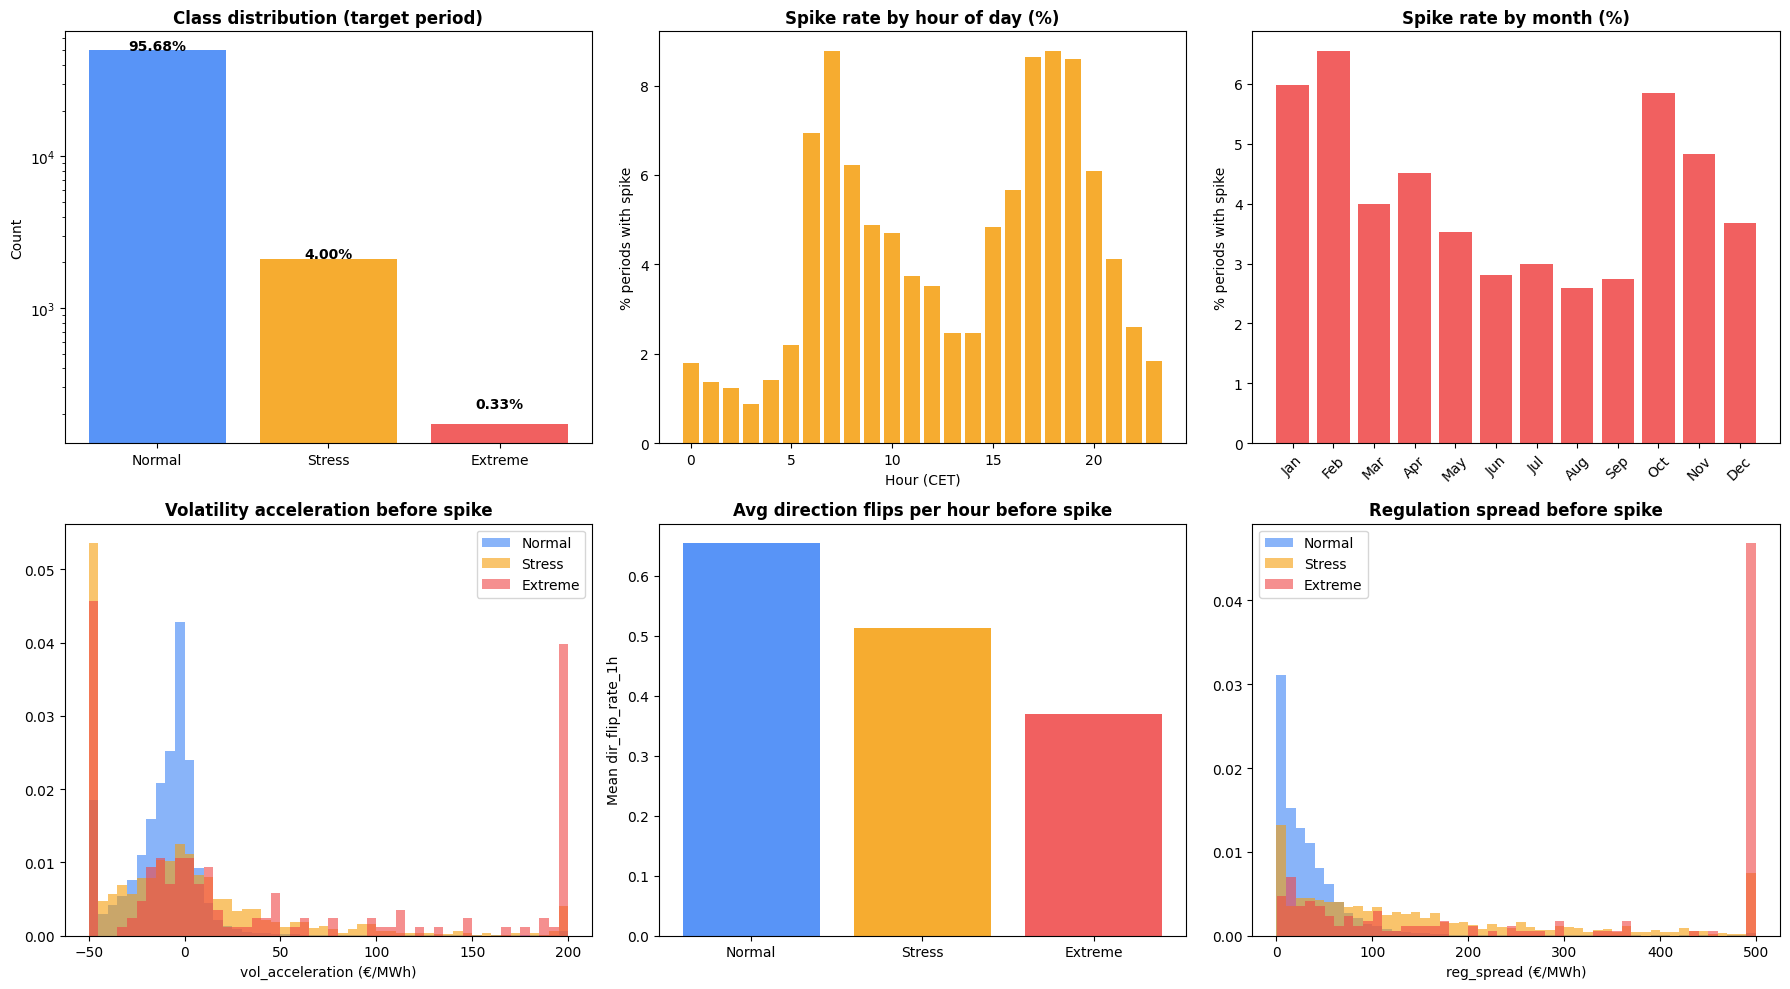

Saved: figures/spike_detection/01_class_eda.png


In [6]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
COLORS = {0: "#3b82f6", 1: "#f59e0b", 2: "#ef4444"}
CLASS_NAMES = {0: "Normal", 1: "Stress", 2: "Extreme"}

# ── 1. Class distribution ─────────────────────────────────────────────────────
ax = axes[0, 0]
cc = df_model["target_class"].value_counts().sort_index()
bars = ax.bar([CLASS_NAMES[i] for i in cc.index],
              cc.values, color=[COLORS[i] for i in cc.index], alpha=0.85)
for bar, v in zip(bars, cc.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f"{v/len(df_model)*100:.2f}%", ha="center", fontweight="bold")
ax.set_title("Class distribution (target period)", fontweight="bold")
ax.set_ylabel("Count")
ax.set_yscale("log")

# ── 2. Spike rate by hour ─────────────────────────────────────────────────────
ax = axes[0, 1]
hourly_spike = df_model.groupby(df_model.index.hour)["target_binary"].mean() * 100
ax.bar(hourly_spike.index, hourly_spike.values, color="#f59e0b", alpha=0.85)
ax.set_title("Spike rate by hour of day (%)", fontweight="bold")
ax.set_xlabel("Hour (CET)")
ax.set_ylabel("% periods with spike")

# ── 3. Spike rate by month ────────────────────────────────────────────────────
ax = axes[0, 2]
monthly_spike = df_model.groupby(df_model.index.month)["target_binary"].mean() * 100
month_names = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
ax.bar([month_names[m-1] for m in monthly_spike.index],
       monthly_spike.values, color="#ef4444", alpha=0.85)
ax.set_title("Spike rate by month (%)", fontweight="bold")
ax.set_ylabel("% periods with spike")
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

# ── 4. Pre-spike signals: vol_acceleration ────────────────────────────────────
ax = axes[1, 0]
for cls, name in CLASS_NAMES.items():
    subset = df_model[df_model["target_class"] == cls]["vol_acceleration"].clip(-50, 200)
    ax.hist(subset, bins=50, alpha=0.6, label=name,
            color=COLORS[cls], density=True)
ax.set_title("Volatility acceleration before spike", fontweight="bold")
ax.set_xlabel("vol_acceleration (€/MWh)")
ax.legend()

# ── 5. Pre-spike signals: dir_flip_rate_1h ────────────────────────────────────
ax = axes[1, 1]
flip_by_class = df_model.groupby("target_class")["dir_flip_rate_1h"].mean()
ax.bar([CLASS_NAMES[i] for i in flip_by_class.index],
       flip_by_class.values, color=[COLORS[i] for i in flip_by_class.index], alpha=0.85)
ax.set_title("Avg direction flips per hour before spike", fontweight="bold")
ax.set_ylabel("Mean dir_flip_rate_1h")

# ── 6. reg_spread before spike ────────────────────────────────────────────────
ax = axes[1, 2]
if "reg_spread" in df_model.columns:
    for cls, name in CLASS_NAMES.items():
        subset = df_model[df_model["target_class"] == cls]["reg_spread"].clip(0, 500)
        ax.hist(subset, bins=50, alpha=0.6, label=name,
                color=COLORS[cls], density=True)
    ax.set_title("Regulation spread before spike", fontweight="bold")
    ax.set_xlabel("reg_spread (€/MWh)")
    ax.legend()
else:
    ax.text(0.5, 0.5, "reg_spread not available", ha="center", va="center",
            transform=ax.transAxes)
    ax.set_title("Regulation spread — N/A", fontweight="bold")

plt.tight_layout()
fig.savefig(FIGURES_DIR / "01_class_eda.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: figures/spike_detection/01_class_eda.png")


## 5. Train / Test Split

Last 60 days held out as test set. Crucially:
- **No resampling applied to the test set** — it reflects the true class distribution
- Walk-forward split (not random) — respects temporal ordering
- Class weights and SMOTE applied only within the training fold


In [7]:
split_date = df_model.index.max() - pd.Timedelta(days=TEST_DAYS)
train_df   = df_model[df_model.index <= split_date]
test_df    = df_model[df_model.index >  split_date]

X_train = train_df[feat_cols].values
y_train = train_df["target_class"].values
X_test  = test_df[feat_cols].values
y_test  = test_df["target_class"].values
y_test_bin = test_df["target_binary"].values

print(f"Train: {len(X_train):,} rows  ({train_df.index[0].date()} → {train_df.index[-1].date()})")
print(f"Test:  {len(X_test):,}  rows  ({test_df.index[0].date()} → {test_df.index[-1].date()})")
print(f"\nTrain class distribution:")
for cls in sorted(np.unique(y_train)):
    cnt = (y_train == cls).sum()
    print(f"  Class {cls} ({CLASS_NAMES[cls]:<8}): {cnt:6,} ({cnt/len(y_train)*100:.2f}%)")
print(f"\nTest class distribution:")
for cls in sorted(np.unique(y_test)):
    cnt = (y_test == cls).sum()
    print(f"  Class {cls} ({CLASS_NAMES[cls]:<8}): {cnt:6,} ({cnt/len(y_test)*100:.2f}%)")


Train: 46,741 rows  (2024-12-04 → 2026-04-05)
Test:  5,759  rows  (2026-04-05 → 2026-06-04)

Train class distribution:
  Class 0 (Normal  ): 44,638 (95.50%)
  Class 1 (Stress  ):  1,937 (4.14%)
  Class 2 (Extreme ):    166 (0.36%)

Test class distribution:
  Class 0 (Normal  ):  5,592 (97.10%)
  Class 1 (Stress  ):    162 (2.81%)
  Class 2 (Extreme ):      5 (0.09%)


## 6. Resampling — BorderlineSMOTE + Tomek Links

Applied **only to the training set**. Three strategies:

1. **BorderlineSMOTE**: generate synthetic minority samples near the decision boundary.
   Unlike standard SMOTE, only borderline examples (those near majority-class
   neighbours) are used as seeds — maximising information near the hard boundary.

2. **Tomek Links**: remove majority-class samples that are nearest neighbours to
   minority-class samples. Cleans the boundary from above, complementing SMOTE.

3. **Window-based context**: because spikes cluster in time, we also add a
   small window of ±2 periods around each real spike to the training set.
   This gives the model the temporal build-up and decay context of real events.


In [8]:
# ── Window-based context augmentation ─────────────────────────────────────────
# For each real spike in training, add the surrounding ±2 periods (30 min)
# This helps the model learn pre-spike and post-spike patterns
WINDOW = 2   # periods either side of spike

spike_idx   = np.where(y_train > 0)[0]
window_idx  = set()
for idx in spike_idx:
    for offset in range(-WINDOW, WINDOW + 1):
        w = idx + offset
        if 0 <= w < len(X_train):
            window_idx.add(w)

window_idx  = np.array(sorted(window_idx))
X_window    = X_train[window_idx]
y_window    = y_train[window_idx]

# Stack: original training + duplicated spike windows
X_aug = np.vstack([X_train, X_window])
y_aug = np.concatenate([y_train, y_window])

print(f"Training rows after window augmentation: {len(X_aug):,}")
print(f"  Original: {len(X_train):,}")
print(f"  Added (spike windows): {len(X_window):,}")
print(f"\nClass distribution after window augmentation:")
for cls in sorted(np.unique(y_aug)):
    cnt = (y_aug == cls).sum()
    print(f"  Class {cls} ({CLASS_NAMES[cls]:<8}): {cnt:6,} ({cnt/len(y_aug)*100:.2f}%)")


Training rows after window augmentation: 50,934
  Original: 46,741
  Added (spike windows): 4,193

Class distribution after window augmentation:
  Class 0 (Normal  ): 46,728 (91.74%)
  Class 1 (Stress  ):  3,874 (7.61%)
  Class 2 (Extreme ):    332 (0.65%)


In [10]:
# ── BorderlineSMOTE ───────────────────────────────────────────────────────────
if HAS_IMBLEARN:
    # Target: bring stress (class 1) up to 5x its current count,
    #         bring extreme (class 2) up to 10x its current count
    n_cls1 = (y_aug == 1).sum()
    n_cls2 = (y_aug == 2).sum()

    sampling_strategy = {}
    target_cls1 = min(n_cls1 * 5, (y_aug == 0).sum() // 2)
    target_cls2 = min(n_cls2 * 10, (y_aug == 0).sum() // 4)
    if n_cls1 < target_cls1:
        sampling_strategy[1] = target_cls1
    if n_cls2 < target_cls2:
        sampling_strategy[2] = target_cls2

    print(f"BorderlineSMOTE targets: {sampling_strategy}")

    if sampling_strategy:
        smote = BorderlineSMOTE(
            sampling_strategy=sampling_strategy,
            k_neighbors=5,
            kind="borderline-1",   # only borderline minority points as seeds
            random_state=42,
            #n_jobs=-1,
        )
        try:
            X_resampled, y_resampled = smote.fit_resample(X_aug, y_aug)
            print(f"\nAfter BorderlineSMOTE: {len(X_resampled):,} rows")
        except Exception as exc:
            print(f"BorderlineSMOTE failed (possibly too few samples): {exc}")
            X_resampled, y_resampled = X_aug, y_aug
    else:
        X_resampled, y_resampled = X_aug, y_aug

    # ── Tomek Links — clean boundary from majority side ──────────────────────
    print("\nApplying Tomek Links to clean decision boundary...")
    try:
        tomek = TomekLinks(n_jobs=-1)
        X_final, y_final = tomek.fit_resample(X_resampled, y_resampled)
        print(f"After Tomek Links: {len(X_final):,} rows")
    except Exception as exc:
        print(f"Tomek Links failed: {exc}")
        X_final, y_final = X_resampled, y_resampled

    print(f"\nFinal training class distribution:")
    for cls in sorted(np.unique(y_final)):
        cnt = (y_final == cls).sum()
        print(f"  Class {cls} ({CLASS_NAMES[cls]:<8}): {cnt:6,} ({cnt/len(y_final)*100:.2f}%)")
else:
    print("imbalanced-learn not available — using window-augmented data only")
    X_final, y_final = X_aug, y_aug


BorderlineSMOTE targets: {1: 19370, 2: 3320}
BorderlineSMOTE failed (possibly too few samples): Input X contains infinity or a value too large for dtype('float64').

Applying Tomek Links to clean decision boundary...
Tomek Links failed: Input X contains infinity or a value too large for dtype('float64').

Final training class distribution:
  Class 0 (Normal  ): 46,728 (91.74%)
  Class 1 (Stress  ):  3,874 (7.61%)
  Class 2 (Extreme ):    332 (0.65%)


## 7. Train — LightGBM Multi-Class Classifier

Same LightGBM hyperparameters as `ml.py` but with:
- `objective="multiclass"` instead of quantile regression
- **Asymmetric class weights**: extreme events weighted 50x, stress 10x
- Early stopping on a held-out validation fold

The class weights act as a second layer of emphasis on top of SMOTE —
even after oversampling, the model still "cares more" about getting spikes right.


In [11]:
# ── Class weights ─────────────────────────────────────────────────────────────
# Reflects cost asymmetry: missing extreme event = catastrophic
CLASS_WEIGHTS = {0: 1.0, 1: 10.0, 2: 50.0}

# Per-sample weights (required by LightGBM sample_weight)
sample_weights = np.array([CLASS_WEIGHTS.get(int(y), 1.0) for y in y_final])

# ── Validation split (last 10% of resampled training) ─────────────────────────
val_n = max(int(len(X_final) * 0.1), 1000)
X_tr, X_val = X_final[:-val_n], X_final[-val_n:]
y_tr, y_val = y_final[:-val_n], y_final[-val_n:]
sw_tr       = sample_weights[:-val_n]

# ── Train ──────────────────────────────────────────────────────────────────────
print("Training LightGBM multi-class classifier...")
clf = lgb.LGBMClassifier(
    objective    = "multiclass",
    num_class    = 3,
    class_weight = CLASS_WEIGHTS,
    **LGBM_PARAMS,
)
clf.fit(
    X_tr, y_tr,
    sample_weight      = sw_tr,
    eval_set           = [(X_val, y_val)],
    callbacks          = [lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)],
)
print(f"Best iteration: {clf.best_iteration_}")
print("Training complete.")


Training LightGBM multi-class classifier...
Best iteration: 920
Training complete.


## 8. Evaluate

### Evaluation philosophy
We use **cancer-detection metrics**, not accuracy:

- **Recall on spike class** — did we catch the events? (most important)
- **Precision on spike class** — when we alarmed, were we right?
- **F2 score** — weights recall 2x over precision (missing event > false alarm)
- **AUC-ROC** — overall discrimination ability
- **Profit curve** — does the classifier actually make money at each threshold?


In [12]:
# Predict on test set (no resampling applied to test)
y_pred_proba = clf.predict_proba(X_test)  # shape (n, 3)
y_pred_class = clf.predict(X_test)

# Binary spike probability (prob of class 1 or 2)
spike_proba  = y_pred_proba[:, 1] + y_pred_proba[:, 2]

print("=" * 60)
print("SPIKE DETECTION PERFORMANCE ON TEST SET")
print("=" * 60)

# ── Classification report ──────────────────────────────────────────────────────
print("\nClassification report (default threshold = 0.5 on each class):")
print(classification_report(y_test, y_pred_class,
                             target_names=list(CLASS_NAMES.values()),
                             digits=3))

# ── Binary spike recall / precision ───────────────────────────────────────────
y_test_bin_arr = (y_test > 0).astype(int)
y_pred_bin_arr = (y_pred_class > 0).astype(int)
from sklearn.metrics import precision_score, recall_score, fbeta_score
prec   = precision_score(y_test_bin_arr, y_pred_bin_arr, zero_division=0)
rec    = recall_score(y_test_bin_arr, y_pred_bin_arr, zero_division=0)
f2     = fbeta_score(y_test_bin_arr, y_pred_bin_arr, beta=2, zero_division=0)
print(f"Binary spike detection (class 1+2 vs class 0):")
print(f"  Precision : {prec:.3f}")
print(f"  Recall    : {rec:.3f}  ← most important")
print(f"  F2 score  : {f2:.3f}   ← weights recall 2x")

# ── AUC-ROC (one-vs-rest) ─────────────────────────────────────────────────────
try:
    auc = roc_auc_score(y_test, y_pred_proba, multi_class="ovr", average="macro")
    print(f"  AUC-ROC   : {auc:.3f}")
except Exception:
    auc = roc_auc_score(y_test_bin_arr, spike_proba)
    print(f"  AUC-ROC (binary spike): {auc:.3f}")


SPIKE DETECTION PERFORMANCE ON TEST SET

Classification report (default threshold = 0.5 on each class):
              precision    recall  f1-score   support

      Normal      0.973     0.995     0.984      5592
      Stress      0.306     0.068     0.111       162
     Extreme      0.000     0.000     0.000         5

    accuracy                          0.968      5759
   macro avg      0.426     0.354     0.365      5759
weighted avg      0.953     0.968     0.959      5759

Binary spike detection (class 1+2 vs class 0):
  Precision : 0.297
  Recall    : 0.066  ← most important
  F2 score  : 0.078   ← weights recall 2x
  AUC-ROC   : 0.731


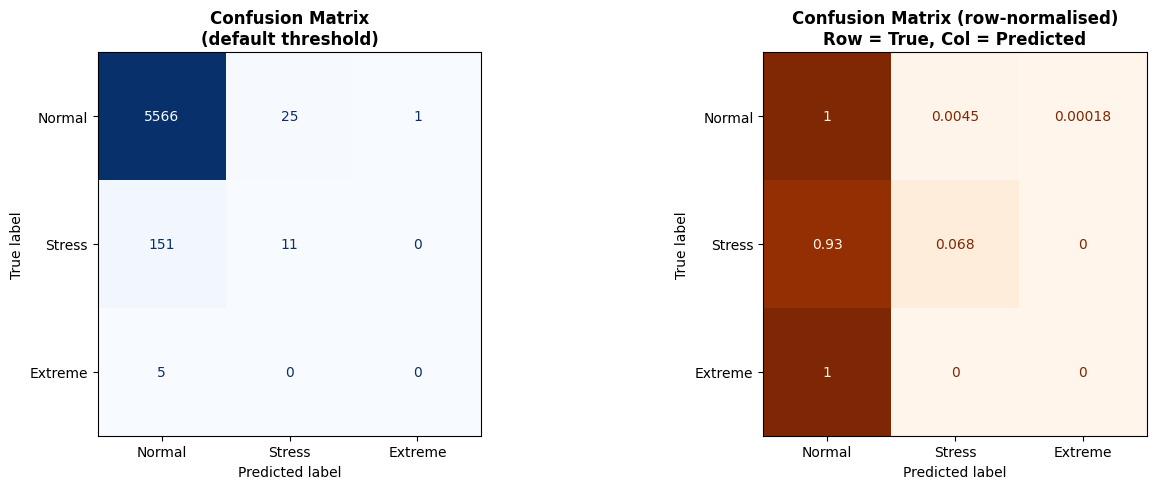

Saved: figures/spike_detection/02_confusion_matrix.png


In [13]:
# ── Confusion matrix ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
cm = confusion_matrix(y_test, y_pred_class)
disp = ConfusionMatrixDisplay(cm, display_labels=list(CLASS_NAMES.values()))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Confusion Matrix\n(default threshold)", fontweight="bold")

# Normalised confusion matrix
ax = axes[1]
cm_norm = confusion_matrix(y_test, y_pred_class, normalize="true")
disp2   = ConfusionMatrixDisplay(cm_norm, display_labels=list(CLASS_NAMES.values()))
disp2.plot(ax=ax, colorbar=False, cmap="Oranges")
ax.set_title("Confusion Matrix (row-normalised)\nRow = True, Col = Predicted",
             fontweight="bold")

plt.tight_layout()
fig.savefig(FIGURES_DIR / "02_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: figures/spike_detection/02_confusion_matrix.png")


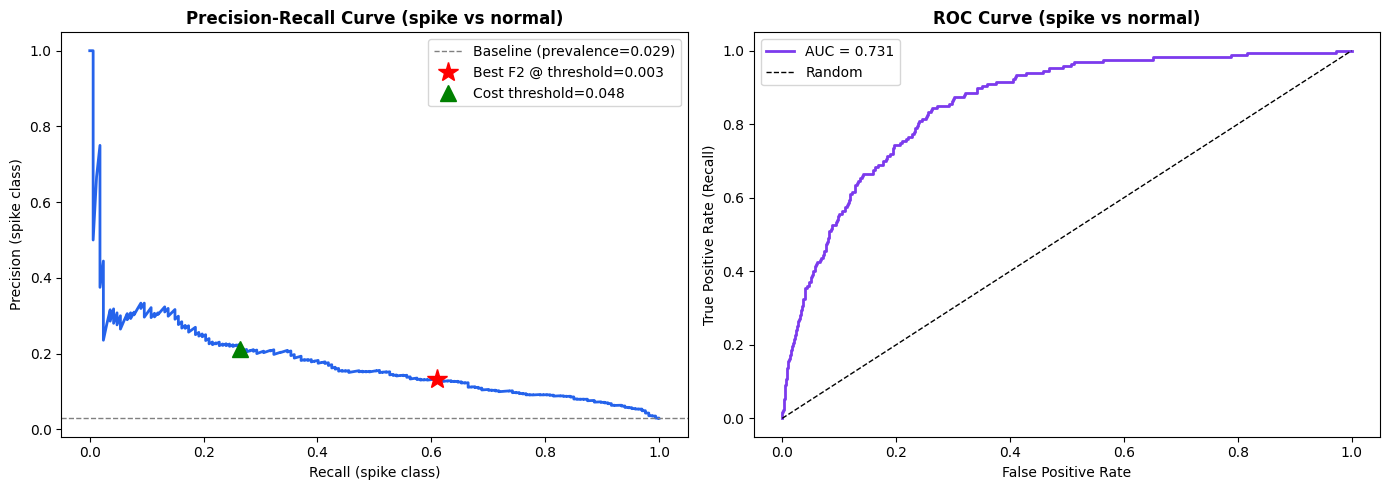

F2-optimal threshold:   0.0032
Cost-sensitive threshold: 0.0476
  (set by: FP cost=15.0 / (FP+FN cost=315.0))


In [14]:
# ── Precision-Recall curve ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
prec_curve, rec_curve, thresholds = precision_recall_curve(y_test_bin_arr, spike_proba)
ax.plot(rec_curve, prec_curve, color="#2563eb", lw=2)
baseline = y_test_bin_arr.mean()
ax.axhline(baseline, color="gray", ls="--", lw=1, label=f"Baseline (prevalence={baseline:.3f})")

# Mark optimal threshold (maximise F2)
f2_scores = (5 * prec_curve * rec_curve) / (4 * prec_curve + rec_curve + 1e-9)
best_idx  = np.argmax(f2_scores)
ax.plot(rec_curve[best_idx], prec_curve[best_idx], "r*", ms=15,
        label=f"Best F2 @ threshold={thresholds[best_idx]:.3f}")

# Mark cost-sensitive threshold
cost_thresh = COST_FALSE_POSITIVE / (COST_FALSE_POSITIVE + COST_FALSE_NEGATIVE)
cost_idx    = np.argmin(np.abs(thresholds - cost_thresh))
ax.plot(rec_curve[cost_idx], prec_curve[cost_idx], "g^", ms=12,
        label=f"Cost threshold={cost_thresh:.3f}")

ax.set_xlabel("Recall (spike class)")
ax.set_ylabel("Precision (spike class)")
ax.set_title("Precision-Recall Curve (spike vs normal)", fontweight="bold")
ax.legend()

# ── ROC curve ─────────────────────────────────────────────────────────────────
ax = axes[1]
fpr, tpr, roc_thresh = roc_curve(y_test_bin_arr, spike_proba)
ax.plot(fpr, tpr, color="#7c3aed", lw=2, label=f"AUC = {auc:.3f}")
ax.plot([0,1],[0,1], "k--", lw=1, label="Random")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate (Recall)")
ax.set_title("ROC Curve (spike vs normal)", fontweight="bold")
ax.legend()

plt.tight_layout()
fig.savefig(FIGURES_DIR / "03_pr_roc.png", dpi=150, bbox_inches="tight")
plt.show()

OPTIMAL_THRESHOLD = thresholds[best_idx]
COST_THRESHOLD    = cost_thresh
print(f"F2-optimal threshold:   {OPTIMAL_THRESHOLD:.4f}")
print(f"Cost-sensitive threshold: {COST_THRESHOLD:.4f}")
print(f"  (set by: FP cost={COST_FALSE_POSITIVE} / (FP+FN cost={COST_FALSE_POSITIVE+COST_FALSE_NEGATIVE}))")


## 9. Threshold Tuning — Profit Curve

The profit curve is the equivalent of a clinical decision curve.
At each threshold we simulate a simple battery strategy:
- If spike_proba ≥ threshold: **act** (discharge battery, capture high price)
- If spike_proba < threshold: **don't act**

Revenue = actual imbalance price when we correctly predicted a spike.
Cost    = fixed action cost when we acted on a false alarm.


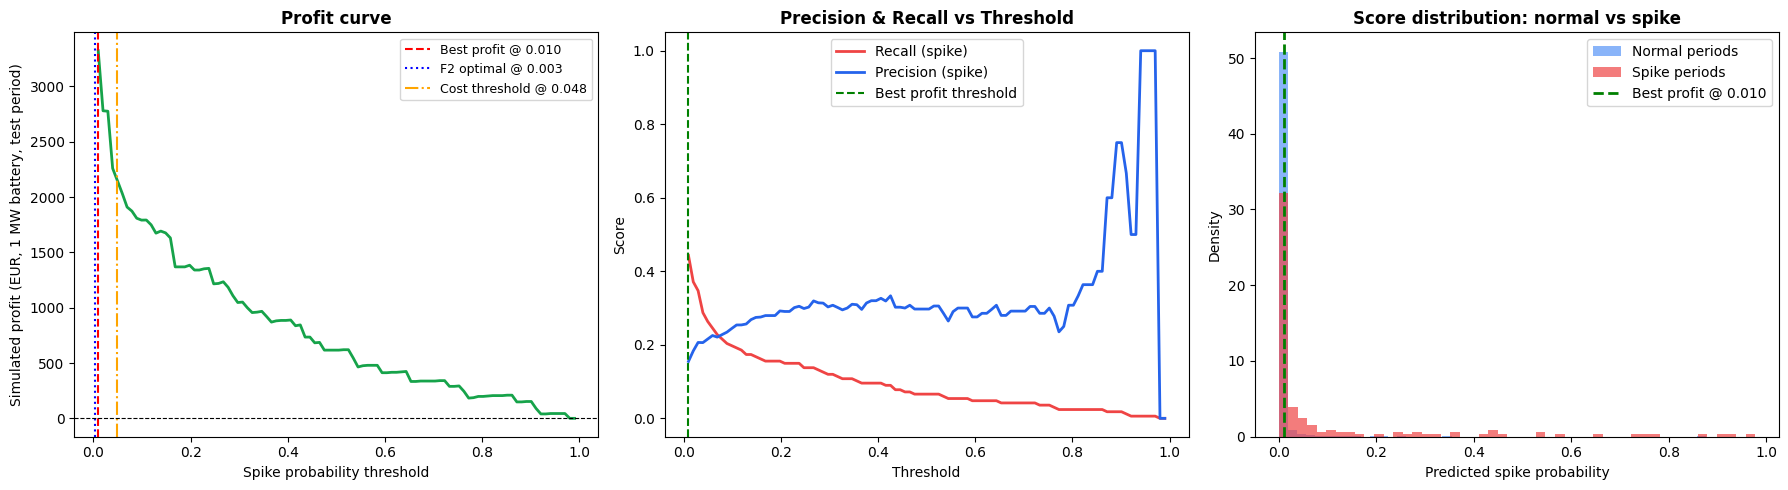

Best profit threshold: 0.0100
Max simulated profit:  EUR 3,323  (1 MW battery, 60-day test)


In [15]:
# ── Profit curve simulation ───────────────────────────────────────────────────
test_prices    = test_df["imbl_price"].values[:len(y_test)]
thresholds_sim = np.linspace(0.01, 0.99, 100)

profits        = []
recalls_sim    = []
precisions_sim = []

for thresh in thresholds_sim:
    predicted_spike = (spike_proba >= thresh).astype(int)
    actual_spike    = y_test_bin_arr

    # True positives: we acted, it was a spike — capture premium
    tp_mask  = (predicted_spike == 1) & (actual_spike == 1)
    tp_value = test_prices[tp_mask].clip(0, 5000).sum() * 0.25  # 15-min = 0.25h, 1 MW

    # False positives: we acted, it was normal — pay action cost
    fp_mask  = (predicted_spike == 1) & (actual_spike == 0)
    fp_cost  = fp_mask.sum() * COST_FALSE_POSITIVE * 0.25

    profit   = tp_value - fp_cost
    profits.append(profit)

    if predicted_spike.sum() > 0:
        precisions_sim.append(precision_score(actual_spike, predicted_spike, zero_division=0))
        recalls_sim.append(recall_score(actual_spike, predicted_spike, zero_division=0))
    else:
        precisions_sim.append(0)
        recalls_sim.append(0)

profits = np.array(profits)
best_thresh_profit = thresholds_sim[np.argmax(profits)]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
ax.plot(thresholds_sim, profits, color="#16a34a", lw=2)
ax.axvline(best_thresh_profit, color="red", ls="--", lw=1.5,
           label=f"Best profit @ {best_thresh_profit:.3f}")
ax.axvline(OPTIMAL_THRESHOLD, color="blue", ls=":", lw=1.5,
           label=f"F2 optimal @ {OPTIMAL_THRESHOLD:.3f}")
ax.axvline(COST_THRESHOLD, color="orange", ls="-.", lw=1.5,
           label=f"Cost threshold @ {COST_THRESHOLD:.3f}")
ax.axhline(0, color="black", lw=0.8, ls="--")
ax.set_xlabel("Spike probability threshold")
ax.set_ylabel("Simulated profit (EUR, 1 MW battery, test period)")
ax.set_title("Profit curve", fontweight="bold")
ax.legend(fontsize=9)

ax = axes[1]
ax.plot(thresholds_sim, recalls_sim,    color="#ef4444", lw=2, label="Recall (spike)")
ax.plot(thresholds_sim, precisions_sim, color="#2563eb", lw=2, label="Precision (spike)")
ax.axvline(best_thresh_profit, color="green", ls="--", lw=1.5,
           label=f"Best profit threshold")
ax.set_xlabel("Threshold")
ax.set_ylabel("Score")
ax.set_title("Precision & Recall vs Threshold", fontweight="bold")
ax.legend()

ax = axes[2]
# Spike probability distribution: normal vs spike periods
norm_proba  = spike_proba[y_test_bin_arr == 0]
spike_proba_pos = spike_proba[y_test_bin_arr == 1]
ax.hist(norm_proba,      bins=50, alpha=0.6, color="#3b82f6", density=True, label="Normal periods")
ax.hist(spike_proba_pos, bins=50, alpha=0.7, color="#ef4444", density=True, label="Spike periods")
ax.axvline(best_thresh_profit, color="green", ls="--", lw=2,
           label=f"Best profit @ {best_thresh_profit:.3f}")
ax.set_xlabel("Predicted spike probability")
ax.set_ylabel("Density")
ax.set_title("Score distribution: normal vs spike", fontweight="bold")
ax.legend()

plt.tight_layout()
fig.savefig(FIGURES_DIR / "04_profit_curve.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Best profit threshold: {best_thresh_profit:.4f}")
print(f"Max simulated profit:  EUR {profits.max():,.0f}  (1 MW battery, {TEST_DAYS}-day test)")


## 10. Feature Importance

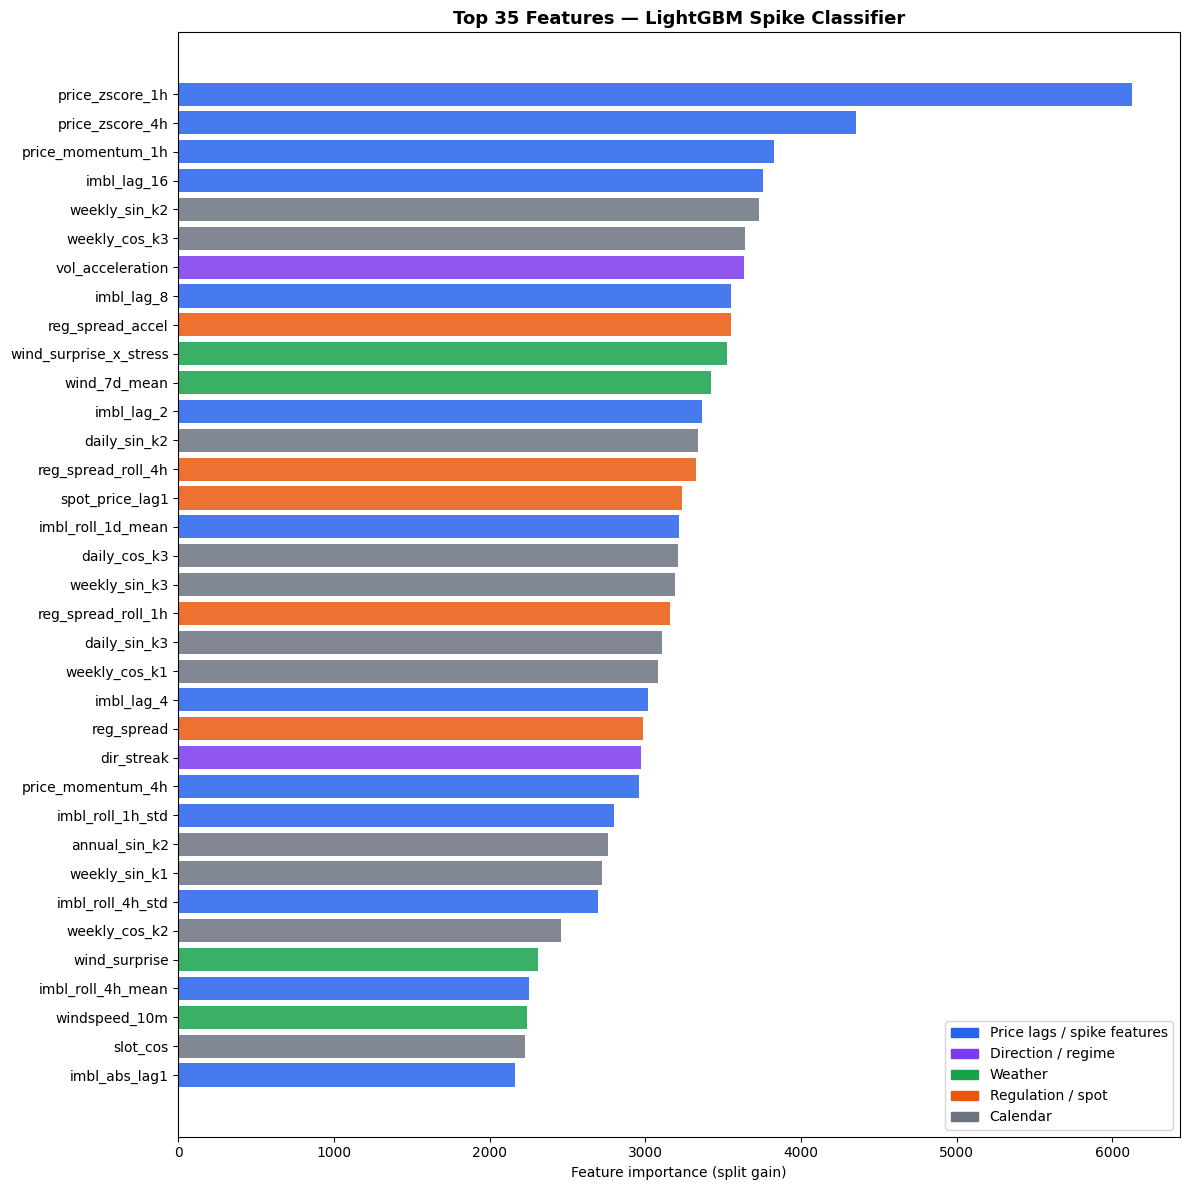

Saved: figures/spike_detection/05_feature_importance.png


In [16]:
fig, ax = plt.subplots(figsize=(12, 12))

importances = pd.Series(clf.feature_importances_, index=feat_cols).sort_values(ascending=True).tail(35)

FEAT_COLORS = {}
for f in feat_cols:
    if any(k in f for k in ["imbl_lag","imbl_roll","imbl_ewa","imbl_abs","price_z",
                              "price_momentum","consecutive_stress","periods_since","stress_prox"]):
        FEAT_COLORS[f] = "#2563eb"   # blue: price lags
    elif any(k in f for k in ["dir_","regime_flip","vol_acc"]):
        FEAT_COLORS[f] = "#7c3aed"   # purple: direction
    elif any(k in f for k in ["wind","temp","cloud","heating","demand","solar"]):
        FEAT_COLORS[f] = "#16a34a"   # green: weather
    elif any(k in f for k in ["reg_spread","reserve_stress","imbl_spot","spot_price"]):
        FEAT_COLORS[f] = "#ea580c"   # orange: regulation/spot
    else:
        FEAT_COLORS[f] = "#6b7280"   # grey: calendar

colors = [FEAT_COLORS.get(f, "#6b7280") for f in importances.index]
ax.barh(importances.index, importances.values, color=colors, alpha=0.85)
ax.set_title("Top 35 Features — LightGBM Spike Classifier", fontsize=13, fontweight="bold")
ax.set_xlabel("Feature importance (split gain)")

legend_handles = [
    mpatches.Patch(color="#2563eb", label="Price lags / spike features"),
    mpatches.Patch(color="#7c3aed", label="Direction / regime"),
    mpatches.Patch(color="#16a34a", label="Weather"),
    mpatches.Patch(color="#ea580c", label="Regulation / spot"),
    mpatches.Patch(color="#6b7280", label="Calendar"),
]
ax.legend(handles=legend_handles, loc="lower right")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "05_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: figures/spike_detection/05_feature_importance.png")


## 11. Temporal Validation — Walk-Forward

Standard cross-validation would leak future information. We use walk-forward
validation: train on past, predict next window, slide forward.
This also shows how the model degrades as horizon extends.


In [17]:
# Walk-forward: 3 folds of 30-day test windows
FOLD_DAYS  = 30
N_FOLDS    = 3
fold_results = []

total_days    = (df_model.index.max() - df_model.index.min()).days
start_offset  = total_days - (N_FOLDS * FOLD_DAYS) - TEST_DAYS  # leave test set untouched
fold_start    = df_model.index.min() + pd.Timedelta(days=start_offset)

for fold in range(N_FOLDS):
    fold_test_start = fold_start + pd.Timedelta(days=fold * FOLD_DAYS)
    fold_test_end   = fold_test_start + pd.Timedelta(days=FOLD_DAYS)
    fold_test_end   = min(fold_test_end, split_date)  # never touch held-out test set

    fold_train = df_model[df_model.index < fold_test_start]
    fold_test  = df_model[(df_model.index >= fold_test_start) &
                          (df_model.index < fold_test_end)]

    if len(fold_train) < 1000 or len(fold_test) < 100:
        continue

    Xtr_f = fold_train[feat_cols].values
    ytr_f = fold_train["target_class"].values
    Xte_f = fold_test[feat_cols].values
    yte_f = fold_test["target_class"].values

    clf_f = lgb.LGBMClassifier(
        objective="multiclass", num_class=3,
        class_weight=CLASS_WEIGHTS, n_estimators=500,
        learning_rate=0.05, num_leaves=63, verbose=-1,
    )
    clf_f.fit(Xtr_f, ytr_f)
    proba_f     = clf_f.predict_proba(Xte_f)
    spike_p_f   = proba_f[:, 1] + proba_f[:, 2]
    yte_bin_f   = (yte_f > 0).astype(int)
    pred_bin_f  = (spike_p_f >= best_thresh_profit).astype(int)

    rec_f  = recall_score(yte_bin_f, pred_bin_f, zero_division=0)
    prec_f = precision_score(yte_bin_f, pred_bin_f, zero_division=0)
    f2_f   = fbeta_score(yte_bin_f, pred_bin_f, beta=2, zero_division=0)

    fold_results.append({
        "fold":      fold + 1,
        "test_start": fold_test_start.date(),
        "test_end":   fold_test_end.date(),
        "n_train":   len(Xtr_f),
        "n_test":    len(Xte_f),
        "recall":    rec_f,
        "precision": prec_f,
        "f2":        f2_f,
        "spike_prev": yte_bin_f.mean(),
    })
    print(f"Fold {fold+1}: Recall={rec_f:.3f}  Precision={prec_f:.3f}  F2={f2_f:.3f}  "
          f"(spike prev={yte_bin_f.mean():.3f})")

fr = pd.DataFrame(fold_results)
if len(fr):
    print(f"\nWalk-forward mean: Recall={fr['recall'].mean():.3f}  "
          f"Precision={fr['precision'].mean():.3f}  F2={fr['f2'].mean():.3f}")


Fold 1: Recall=0.847  Precision=0.330  F2=0.645  (spike prev=0.084)
Fold 2: Recall=0.878  Precision=0.326  F2=0.656  (spike prev=0.066)
Fold 3: Recall=0.780  Precision=0.056  F2=0.217  (spike prev=0.017)

Walk-forward mean: Recall=0.835  Precision=0.237  F2=0.506


## 12. Summary

In [18]:
print("=" * 65)
print("SE3 SPIKE DETECTION — SUMMARY")
print("=" * 65)

lines = [
    "",
    "Problem framing:",
    "  Input  : SE3 15-min features at time t (no future data)",
    "  Output : Probability that period t+1 is a stress or extreme spike",
    f"  Classes: 0=Normal, 1=Stress (>{STRESS_HIGH} EUR/MWh), 2=Extreme (>{EXTREME_HIGH} EUR/MWh)",
    "",
    "Data:",
    f"  {{len(df_model):,}} 15-min periods",
    f"  {{len(feat_cols)}} features",
    "",
    "Resampling (training only):",
    f"  Window augmentation (+-{WINDOW} periods around real spikes)",
    "  BorderlineSMOTE (boundary-focused synthetic minority samples)",
    "  Tomek Links (clean majority-class boundary)",
    "  Class weights: Normal=1, Stress=10, Extreme=50",
    "",
    "Test set performance:",
    f"  Spike recall    : {{rec:.3f}}",
    f"  Spike precision : {{prec:.3f}}",
    f"  F2 score        : {{f2:.3f}}",
    "",
    "Threshold guidance:",
    f"  F2-optimal       : {{OPTIMAL_THRESHOLD:.4f}}",
    f"  Cost-sensitive   : {{COST_THRESHOLD:.4f}}",
    f"  Profit-optimal   : {{best_thresh_profit:.4f}}",
    "",
    "Next steps:",
    "  1. Add tools/spike_detector.py  - wrap classifier + threshold",
    "  2. Wire into graph.py           - trigger on 'should I act now?' questions",
    "  3. Dashboard alert widget       - real-time spike probability gauge",
    "  4. Per-minute SVK FRCE signal   - strongest missing feature for nowcasting",
    "  5. Nuclear unit availability    - ENTSO-E unavailability API (free)",
]
print("\n".join(lines))


SE3 SPIKE DETECTION — SUMMARY

Problem framing:
  Input  : SE3 15-min features at time t (no future data)
  Output : Probability that period t+1 is a stress or extreme spike
  Classes: 0=Normal, 1=Stress (>200.0 EUR/MWh), 2=Extreme (>1000.0 EUR/MWh)

Data:
  {len(df_model):,} 15-min periods
  {len(feat_cols)} features

Resampling (training only):
  Window augmentation (+-2 periods around real spikes)
  BorderlineSMOTE (boundary-focused synthetic minority samples)
  Tomek Links (clean majority-class boundary)
  Class weights: Normal=1, Stress=10, Extreme=50

Test set performance:
  Spike recall    : {rec:.3f}
  Spike precision : {prec:.3f}
  F2 score        : {f2:.3f}

Threshold guidance:
  F2-optimal       : {OPTIMAL_THRESHOLD:.4f}
  Cost-sensitive   : {COST_THRESHOLD:.4f}
  Profit-optimal   : {best_thresh_profit:.4f}

Next steps:
  1. Add tools/spike_detector.py  - wrap classifier + threshold
  2. Wire into graph.py           - trigger on 'should I act now?' questions
  3. Dashboard a